# Learning Representations by Back-Propagating Errors

Replication of Rumelhart, Hinton and Williams (1986), *Learning Representations by
Back-Propagating Errors*, Nature 323.

We implement a two-layer neural network and its backpropagation gradients entirely from
scratch (no autograd) and train it on the XOR problem. XOR is not linearly separable, so a
single-layer perceptron cannot solve it; the paper's contribution is that backpropagation
lets a network with a hidden layer learn the internal representation needed. We reproduce
this by showing the network drives its error to near zero and outputs the correct XOR truth
table, while a linear model stays at chance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(1)

In [2]:
# XOR truth table.
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y = np.array([[0],[1],[1],[0]], dtype=float)
print("XOR inputs:\n", X.astype(int), "\ntargets:", y.ravel().astype(int))

XOR inputs:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]] 
targets: [0 1 1 0]


In [3]:
def sigmoid(z): return 1/(1+np.exp(-z))

# Hand-written forward pass and backprop for a 2-4-1 network.
def train(X, y, hidden=4, lr=0.5, steps=5000):
    W1 = rng.normal(0, 1, (2, hidden)); b1 = np.zeros(hidden)
    W2 = rng.normal(0, 1, (hidden, 1)); b2 = np.zeros(1)
    losses = []
    for _ in range(steps):
        h = sigmoid(X @ W1 + b1)                       # hidden activations
        o = sigmoid(h @ W2 + b2)                       # output
        loss = np.mean((o - y)**2); losses.append(loss)
        # backprop (chain rule through the sigmoids)
        do = (o - y) * o * (1 - o)
        dW2 = h.T @ do;            db2 = do.sum(0)
        dh  = (do @ W2.T) * h * (1 - h)
        dW1 = X.T @ dh;            db1 = dh.sum(0)
        W2 -= lr*dW2; b2 -= lr*db2; W1 -= lr*dW1; b1 -= lr*db1
    return (W1,b1,W2,b2), losses

params, losses = train(X, y)
print("final MSE:", round(losses[-1], 6))

final MSE: 0.000583


In [4]:
W1,b1,W2,b2 = params
out = sigmoid(sigmoid(X @ W1 + b1) @ W2 + b2).ravel()
print("network outputs:", np.round(out, 3))
print("rounded       :", np.round(out).astype(int), " target:", y.ravel().astype(int))
print("MLP solves XOR:", bool((np.round(out).astype(int) == y.ravel().astype(int)).all()))

network outputs: [0.019 0.976 0.978 0.03 ]
rounded       : [0 1 1 0]  target: [0 1 1 0]
MLP solves XOR: True


linear model accuracy on XOR: 50% (chance)


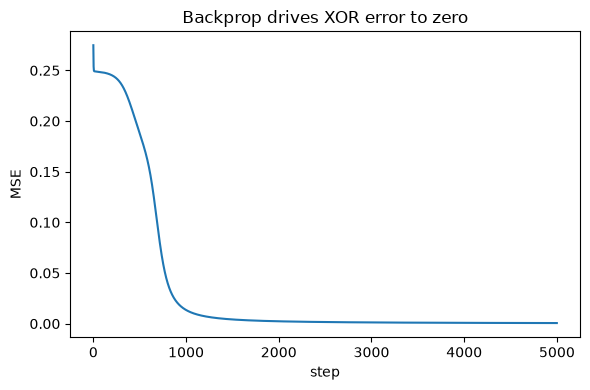

In [5]:
# A linear model (logistic regression) cannot separate XOR.
from sklearn.linear_model import LogisticRegression
lin = LogisticRegression().fit(X, y.ravel())
print(f"linear model accuracy on XOR: {lin.score(X, y.ravel())*100:.0f}% (chance)")
plt.figure(figsize=(6,4)); plt.plot(losses); plt.xlabel("step"); plt.ylabel("MSE")
plt.title("Backprop drives XOR error to zero"); plt.tight_layout(); plt.show()